In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('Imports OK')

Imports OK


In [2]:
class IncomeDataset(Dataset):
    def __init__(self, csv_file):
        self.data = pd.read_csv(csv_file)
        if self.data.columns[0] == '':
            self.data = self.data.iloc[:, 1:]

        self.X = self.data['Education'].values.astype(np.float32).reshape(-1, 1)
        self.y = self.data['Income'].values.astype(np.float32).reshape(-1, 1)

        self.X_mean = self.X.mean()
        self.X_std = self.X.std()
        self.y_mean = self.y.mean()
        self.y_std = self.y.std()

        self.X = (self.X - self.X_mean) / self.X_std
        self.y = (self.y - self.y_mean) / self.y_std

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        X = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.y[idx], dtype=torch.float32)
        return X, y

print('IncomeDataset OK')

IncomeDataset OK


In [3]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_size=1, output_size=1):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)

print('LinearRegressionModel OK')

LinearRegressionModel OK


In [4]:
def train_model(model, train_loader, num_epochs=100, learning_rate=0.01, device='cpu'):
    criterion = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)
    losses = []

    for epoch in range(num_epochs):
        total_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        average_loss = total_loss / len(train_loader)
        losses.append(average_loss)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {average_loss:.4f}')

    print('Treinamento concluido!')
    return losses

print('train_model OK')

train_model OK


In [6]:
print('=== REGRESSAO LINEAR COM PYTORCH ===')
print()

csv_file = 'Income1.csv'
batch_size = 4
num_epochs = 200
learning_rate = 0.01

print('Carregando dados...')
dataset = IncomeDataset(csv_file)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(f'Dataset criado com {len(dataset)} amostras')
print()

print('Criando modelo...')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = LinearRegressionModel(input_size=1, output_size=1).to(device)
print(f'Modelo criado e movido para {device}')
print()

print(f'Treinando modelo em {device}...')
print()
losses = train_model(model, train_loader, num_epochs=num_epochs, learning_rate=learning_rate, device=device)

=== REGRESSAO LINEAR COM PYTORCH ===

Carregando dados...
Dataset criado com 30 amostras

Criando modelo...
Modelo criado e movido para cpu

Treinando modelo em cpu...

Epoch [10/200], Loss: 0.1183
Epoch [20/200], Loss: 0.0699
Epoch [30/200], Loss: 0.0680
Epoch [40/200], Loss: 0.0662
Epoch [50/200], Loss: 0.0718
Epoch [60/200], Loss: 0.0697
Epoch [70/200], Loss: 0.0733
Epoch [80/200], Loss: 0.0809
Epoch [90/200], Loss: 0.0709
Epoch [100/200], Loss: 0.0722
Epoch [110/200], Loss: 0.0707
Epoch [120/200], Loss: 0.0745
Epoch [130/200], Loss: 0.0738
Epoch [140/200], Loss: 0.0661
Epoch [150/200], Loss: 0.0692
Epoch [160/200], Loss: 0.0688
Epoch [170/200], Loss: 0.0654
Epoch [180/200], Loss: 0.0656
Epoch [190/200], Loss: 0.0679
Epoch [200/200], Loss: 0.0668
Treinamento concluido!


In [7]:
print('\n=== AVALIACAO ===')
model.eval()
with torch.no_grad():
    total_mse = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        predictions = model(X_batch)
        mse = nn.MSELoss()(predictions, y_batch)
        total_mse += mse.item()

    avg_mse = total_mse / len(train_loader)
    print(f'MSE no conjunto de treinamento: {avg_mse:.6f}')
    print(f'RMSE: {np.sqrt(avg_mse):.6f}')


=== AVALIACAO ===
MSE no conjunto de treinamento: 0.073880
RMSE: 0.271809


In [8]:
with torch.no_grad():
    weight = model.linear.weight.item()
    bias = model.linear.bias.item()

print(f'\nParametros do Modelo:')
print(f'Peso (w): {weight:.6f}')
print(f'Vies (b): {bias:.6f}')


Parametros do Modelo:
Peso (w): 0.962799
Vies (b): 0.003337


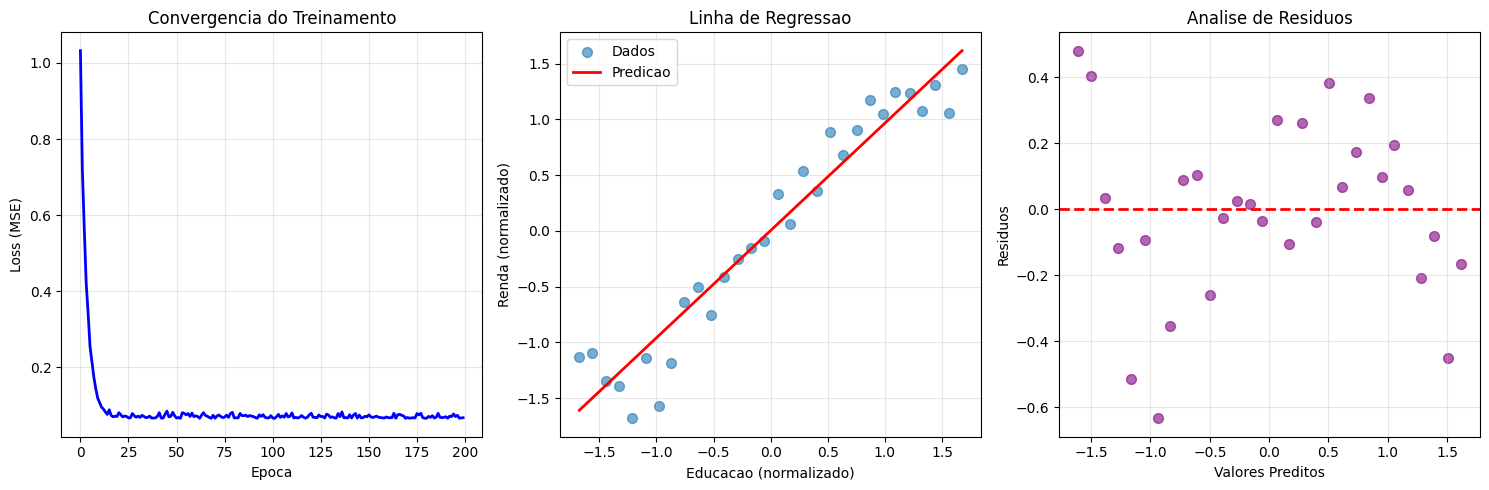

In [9]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(losses, 'b-', linewidth=2)
plt.xlabel('Epoca')
plt.ylabel('Loss (MSE)')
plt.title('Convergencia do Treinamento')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
X_norm = dataset.X.flatten()
y_norm = dataset.y.flatten()
plt.scatter(X_norm, y_norm, alpha=0.6, s=50, label='Dados')
x_line = np.linspace(X_norm.min(), X_norm.max(), 100)
y_line_pred = model(torch.tensor(x_line.reshape(-1, 1), dtype=torch.float32).to(device)).cpu().detach().numpy()
plt.plot(x_line, y_line_pred, 'r-', linewidth=2, label='Predicao')
plt.xlabel('Educacao (normalizado)')
plt.ylabel('Renda (normalizado)')
plt.title('Linha de Regressao')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
X_tensor = torch.tensor(X_norm.reshape(-1, 1), dtype=torch.float32).to(device)
y_pred = model(X_tensor).cpu().detach().numpy().flatten()
residuos = y_norm - y_pred
plt.scatter(y_pred, residuos, alpha=0.6, s=50, color='purple')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Valores Preditos')
plt.ylabel('Residuos')
plt.title('Analise de Residuos')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print('\n=== SALVANDO MODELO ===')
model_path = 'linear_regression_model.pt'
torch.save(model.state_dict(), model_path)
print(f'Parametros salvos em: {model_path}')

model_full_path = 'linear_regression_model_full.pth'
torch.save(model, model_full_path)
print(f'Modelo completo salvo em: {model_full_path}')


=== SALVANDO MODELO ===
Parametros salvos em: linear_regression_model.pt
Modelo completo salvo em: linear_regression_model_full.pth
